# Vowel category learning: two-factor VaDE and supervised baselines

This notebook runs the complete experiment from `metadata_vowels_acoustics.csv`: select 10 speakers, retain every selected vowel, split 80/10/10, preprocess, train, evaluate, and inspect saved results. All reusable implementation is in the adjacent `.py` modules; all settings live in `configs/vowels.py`.

**Reconstruction provenance.** The architecture and ELBO + interaction penalty were recovered from *Build Toy GMVAE*. The original real-data code, selected speakers, seed, hyperparameters, and three-model variants were not accessible. This is a documented reconstruction with three comparison methods (GMVAE, 15-NN, and a supervised neural classifier), not a claim to reproduce the old numeric results exactly. No hyperparameters are chosen to match the remembered accuracies.

## 1. Select the Anaconda kernel and load the configuration

Use the `lffl` Anaconda interpreter (or another environment containing `src/requirements.txt`). The run below was prepared for CPU. To make a new environment, run `conda env create -f src/environment.yml`. For server runs, use `python src/train.py --config src/configs/vowels.py` from the repository root.

Edit the Python config for permanent changes. The example overrides below apply only to this notebook run; the resolved configuration is saved with every result.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'metadata_vowels_acoustics.csv').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src' / 'configs' / 'vowels.py').exists(), 'Run from the repository or src directory.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dataclasses import asdict
from pprint import pprint
from src.config import load_config

config = load_config(ROOT / 'src' / 'configs' / 'vowels.py')
# Optional overrides (edit the config file to retain these for CLI/server runs):
# config.training.epochs = 150
# config.training.device = 'cuda'
# config.data.seed = 123
# config.methods = ('gmvae',)
print('Interpreter:', sys.executable)
pprint(asdict(config))

Interpreter: C:\Users\46021\.conda\envs\lffl\python.exe
{'data': {'csv_path': 'metadata_vowels_acoustics.csv',
          'features': ('f0_median_hz', 'f1_hz', 'f2_hz', 'f3_hz', 'duration_s'),
          'log_features': False,
          'n_speakers': 10,
          'seed': 2026,
          'speaker_ids': None,
          'split': (0.8, 0.1, 0.1)},
 'knn_neighbors': 15,
 'methods': ('gmvae', 'knn', 'classifier'),
 'model': {'eval_mc_samples': 32,
           'hidden_dims': (128, 128),
           'interaction_weight': 10.0,
           'latent_dim': 8,
           'learn_mixture_weights': False,
           'observation_variance': 0.1,
           'train_mc_samples': 4},
 'output_dir': 'outputs/vowels',
 'training': {'batch_size': 512,
              'device': 'cpu',
              'epochs': 100,
              'grad_clip': 10.0,
              'learning_rate': 0.001,
              'min_delta': 0.0001,
              'num_threads': 4,
              'patience': 20,
              'pretrain_epochs': 20,
 

## 2. Load, split, and preprocess the acoustic features

The inputs are median f0, F1, F2, F3 (Hz), and duration (seconds). These are **five input features**; the two categorical factors are phoneme and speaker, and the continuous latent dimension is independently configurable (default 8).

Ten distinct speakers are sampled from a sorted list with seed 2026. Every row from those speakers is retained, without class balancing or downsampling. Tokens are split with joint speaker × phoneme stratification. Integer rounding gives approximately 80/10/10. All speakers occur in each partition: this measures recognition of held-out tokens from known speakers, not generalization to new speakers. Tokens from the same sentence/recording can occur in different partitions.

Nonfinite/nonpositive feature values are marked missing. Medians are fitted on training rows, then used to impute each split. Standardization also uses training statistics only. The default keeps physical feature values before standardization; optional log preprocessing is in the config. No missingness flags or additional acoustic features are added.

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display, Image
from src.data import prepare_data

# Module implementation: data.py
vowels = prepare_data(config.data)
print('Selected speakers:', vowels.speakers)
print('Phonemes:', vowels.phonemes)
print('Rows:', vowels.metadata['split_counts'])
display(pd.Series(vowels.metadata['missing_or_invalid'], name='Missing/invalid selected values').to_frame())
display(pd.crosstab(vowels.frame.speaker_id, vowels.frame.label))
display(pd.DataFrame(vowels.x['train'], columns=config.data.features).describe())

Selected speakers: ['jvs003', 'jvs009', 'jvs018', 'jvs036', 'jvs037', 'jvs038', 'jvs046', 'jvs061', 'jvs065', 'jvs078']
Phonemes: ['a', 'e', 'i', 'o', 'u']
Rows: {'train': 36866, 'val': 4608, 'test': 4609}


,Missing/invalid selected values
f0_median_hz,14970
f1_hz,94
f2_hz,94
f3_hz,94
duration_s,94


label,a,e,i,o,u
speaker_id,,,,,
jvs003,1128,647,783,1191,835
jvs009,1147,660,785,1204,842
jvs018,1157,668,811,1233,859
jvs036,1136,658,780,1216,830
jvs037,1087,648,786,1179,828
jvs038,1112,634,783,1174,850
jvs046,1132,658,784,1198,820
jvs061,1131,663,783,1213,838
jvs065,1154,646,787,1178,865


,f0_median_hz,f1_hz,f2_hz,f3_hz,duration_s
count,3.686600e+04,3.686600e+04,3.686600e+04,3.686600e+04,3.686600e+04
mean,1.034747e-08,-2.069493e-10,-1.034747e-10,2.069493e-10,2.690342e-09
std,1.000071e+00,1.000013e+00,1.000015e+00,1.000012e+00,1.000009e+00
min,-2.034104e+00,-2.092333e+00,-2.683106e+00,-3.801887e+00,-1.704849e+00
25%,-5.500095e-01,-7.028532e-01,-7.457351e-01,-6.629803e-01,-7.113825e-01
50%,-1.047020e-01,-3.493889e-01,-8.721287e-02,-7.079074e-02,-2.002742e-01
75%,3.684687e-01,5.044599e-01,6.297848e-01,7.125604e-01,5.663882e-01
max,4.755589e+00,9.051495e+00,3.823627e+00,5.181121e+00,1.513297e+01


In [3]:
# Check that every selected row is used exactly once and all model inputs are finite.
all_indices = np.concatenate(list(vowels.indices.values()))
assert np.array_equal(np.sort(all_indices), np.arange(len(vowels.frame)))
assert len(np.unique(all_indices)) == len(vowels.frame)
assert all(np.isfinite(x).all() for x in vowels.x.values())
assert len(vowels.speakers) == config.data.n_speakers
print('Data integrity checks passed.')

Data integrity checks passed.


## 3. Understand the model and objectives

The unsupervised model has the generative structure $(c_\phi,c_s)\rightarrow z\rightarrow x$ with 5 phoneme slots and 10 speaker slots, inferred from the label vocabulary. Labels provide category counts and split strata but are **not used in GMVAE gradient updates, initialization, or checkpoint selection**.

The encoder is `5 → 128 → 128 → (mean_z, logvar_z)`. ReLU hidden layers provide nonlinearity. The decoder is `8 → 128 → 128 → 5`, with a fixed diagonal Gaussian observation variance of 0.1 in standardized feature units. The 50 diagonal Gaussian prior components have means

$$\mu_{ij}=\mu_0+a_i+b_j+\widetilde h_{ij}.$$

The phoneme/speaker effects are centered and the interaction is double-centered. Component diagonal variances are learned. The default categorical priors are uniform and factorized; learned factorized weights are optional.

The Gaussian encoder is sampled by reparameterization. Bayes responsibilities $p(i,j\mid z)$ are averaged over 4 samples in training and 32 at prediction time. Marginalization supplies the two category probabilities. The VaDE-style loss is

$$-\mathbb E_q\log p(x\mid z)+\sum_{ij}q_{ij}(x)\,\mathrm{KL}[q(z\mid x)\Vert p(z\mid i,j)]+\mathrm{KL}[q_{ij}(x)\Vert\pi_i\pi_j]+\lambda_h\operatorname{mean}(\widetilde h^2).$$

Here $q_{ij}(x)\approx\mathbb E_{q(z\mid x)}p(i,j\mid z)$ uses Monte Carlo, Gaussian KL terms are analytic, and gradients pass through responsibilities. This follows the recovered **mean-field VaDE-style** description; it is not the alternative collapsed mixture-prior ELBO. The interaction normalization is explicitly a mean square (so lambda 10 is not interchangeable with lambda 10 on a sum). There is no MI reward, label loss, or KL annealing.

Initialization first trains the deterministic autoencoder for 20 epochs on training inputs. KMeans then finds 5 centers in the encoded vectors and 10 centers in their residuals, initializing the additive prior. This ordering is an inductive bias, not evidence that the axes represent phoneme/speaker.

In [4]:
from src.models import TwoFactorVaDE, VowelClassifier

gmvae = TwoFactorVaDE(len(config.data.features), len(vowels.phonemes), len(vowels.speakers), config.model)
classifier = VowelClassifier(len(config.data.features), len(vowels.phonemes), len(vowels.speakers), config.model)
print(gmvae)
print('\nSupervised classifier:', classifier)
print('\nTrainable parameters:', {
    'gmvae': sum(p.numel() for p in gmvae.parameters() if p.requires_grad),
    'classifier': sum(p.numel() for p in classifier.parameters() if p.requires_grad),
})

TwoFactorVaDE(
  (encoder): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (z_mean): Linear(in_features=128, out_features=8, bias=True)
  (z_logvar): Linear(in_features=128, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Sequential(
      (0): Linear(in_features=8, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
    )
    (1): Linear(in_features=128, out_features=5, bias=True)
  )
)

Supervised classifier: VowelClassifier(
  (encoder): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (bottleneck): Linear(in_features=128, out_features=8, bias=True)
  (phoneme_head): Linear(in_features=8, out_features=5, bias=True)
  (speaker_head): Linear(in_features

## 4. Train and evaluate all configured methods

`training.py` implements Adam, gradient clipping, validation loss selection, and patience-based early stopping. The defaults allow 100 training epochs with patience 20; each model is restored to its best validation checkpoint. GMVAE selection uses unsupervised loss, and the classifier uses the sum of two cross-entropies.

The supervised classifier has the same hidden encoder dimensions and an 8-dimensional bottleneck, followed by separate phoneme and speaker softmax heads. It has no decoder. The 15-NN baseline uses Euclidean distances on exactly the same preprocessed features and uniform label votes. **15-NN is supervised classification**, not unsupervised clustering. Differences in supervision are part of the comparison.

For GMVAE, a one-to-one Hungarian category-to-label mapping is fitted on **training predictions and labels** and frozen for validation/test scoring. The raw cluster IDs are also saved. A separate split-optimal permutation accuracy is provided only as a descriptive clustering statistic; it is not used to select checkpoints.

The next cell performs actual training. Re-running it creates a new directory and does not overwrite a previous run. To explore an existing run without retraining, replace this cell with `run_dir = Path('...')`.

In [5]:
from src.experiment import run_experiment

run_dir = run_experiment(config, data=vowels)
print('All artifacts:', run_dir)

Run: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\vowels\20260924_164535_c90671
Speakers: jvs003, jvs009, jvs018, jvs036, jvs037, jvs038, jvs046, jvs061, jvs065, jvs078
Rows: {'train': 36866, 'val': 4608, 'test': 4609}


Training gmvae...


  autoencoder   1: MSE=0.31799


  autoencoder  10: MSE=0.00042


  autoencoder  20: MSE=0.00035


...

  classifier  90: train=1.7869 val=1.8471


  classifier 100: train=1.7732 val=1.8517


  test: phoneme=83.944%, speaker=49.186%


    method split  phoneme_accuracy  speaker_accuracy  joint_accuracy  phoneme_balanced_accuracy  speaker_balanced_accuracy
     gmvae   val          0.556424          0.216363        0.126302                   0.528329                   0.215613
     gmvae  test          0.564982          0.213929        0.122152                   0.537840                   0.213173
       knn   val          0.825955          0.510851        0.458333                   0.812459                   0.510429
       knn  test          0.825776          0.497939        0.447603                   0.812892                   0.497461
classifier   val          0.826389          0.493707        0.438585                   0.812995                   0.493143
classifier  test          0.839445          0.491864        0.439575                   0.827534                   0.491522


All artifacts: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\vowels\20260924_164535_c90671


## 5. Inspect held-out recognition and collapse diagnostics

The primary comparison is test phoneme accuracy, speaker accuracy, and joint accuracy (both marginal predictions correct on the same token). Balanced accuracy is also saved because category frequencies are unequal. GMVAE metrics include ARI, NMI, posterior entropy, mutual information, and the number of categories used by argmax. Low recognition alone does not distinguish collapse from a different acoustic partition.

Scores below come from this run. They are not copied from the remembered ~80% / ~40% experiment.

,split,phoneme_accuracy,speaker_accuracy,joint_accuracy,phoneme_balanced_accuracy,speaker_balanced_accuracy
method,,,,,,
gmvae,test,0.564982,0.213929,0.122152,0.537840,0.213173
knn,test,0.825776,0.497939,0.447603,0.812892,0.497461
classifier,test,0.839445,0.491864,0.439575,0.827534,0.491522


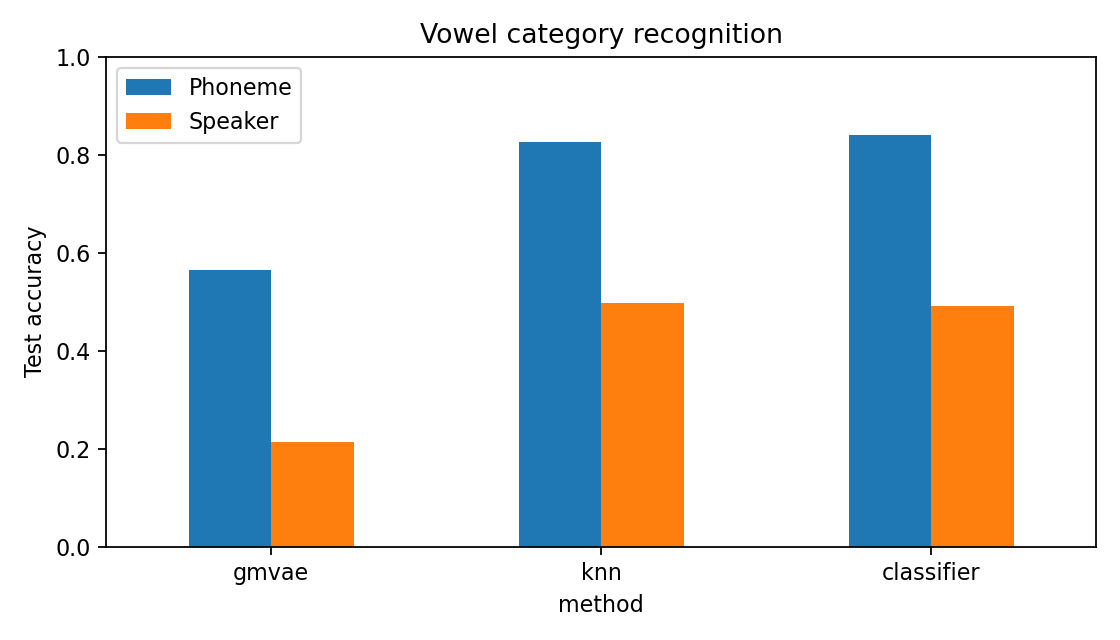

GMVAE held-out diagnostics:
{'joint': {'active_argmax_categories': 47,
           'conditional_entropy_nats': 2.9997639656066895,
           'mean_probabilities': [0.019640713930130005,
                                  0.02003178559243679,
                                  0.020984133705496788,
                                  0.020034460350871086,
                                  0.01986115239560604,
                                  0.018667543306946754,
                                  0.02001994103193283,
                                  0.020005963742733,
                                  0.020025424659252167,
                                  0.018118329346179962,
                                  0.020899444818496704,
                                  0.020343083888292313,
                                  0.01955716870725155,
                                  0.020345773547887802,
                                  0.018852246925234795,
                                  0.0

In [6]:
import json

summary = pd.read_csv(run_dir / 'summary.csv')
display(summary[summary['split'] == 'test'].set_index('method'))
display(Image(filename=str(run_dir / 'accuracy.png')))
metrics = json.loads((run_dir / 'metrics.json').read_text(encoding='utf-8'))
if 'gmvae' in metrics:
    print('GMVAE held-out diagnostics:')
    pprint(metrics['gmvae']['test']['mixture_diagnostics'])
    print('Descriptive test-optimal alignment (not checkpoint selection):')
    pprint(metrics['gmvae']['test']['split_optimal_alignment_accuracy'])

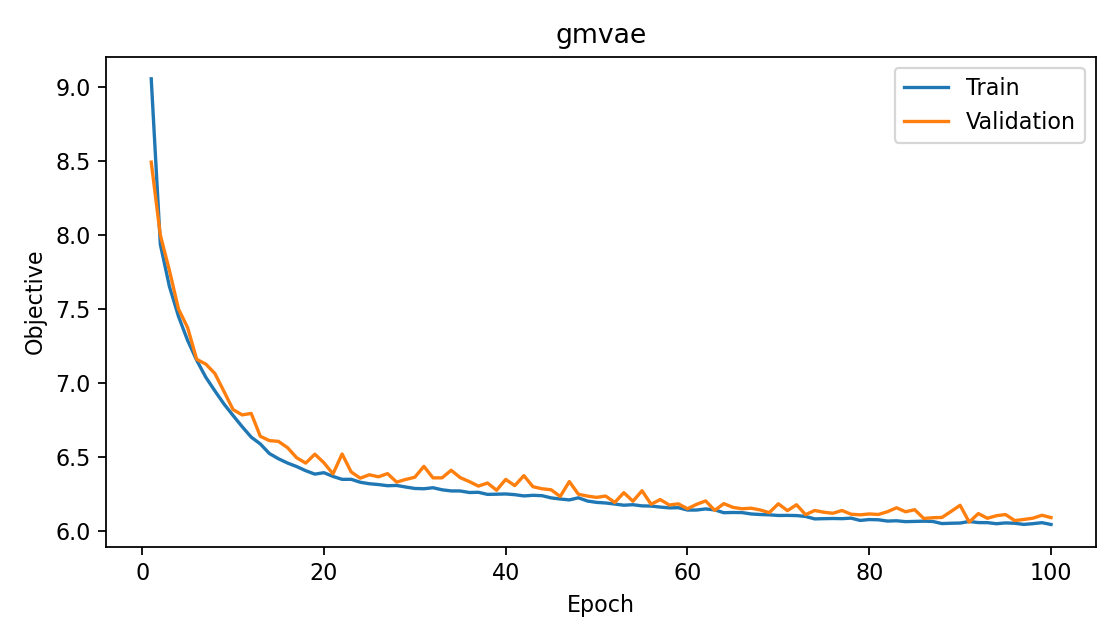

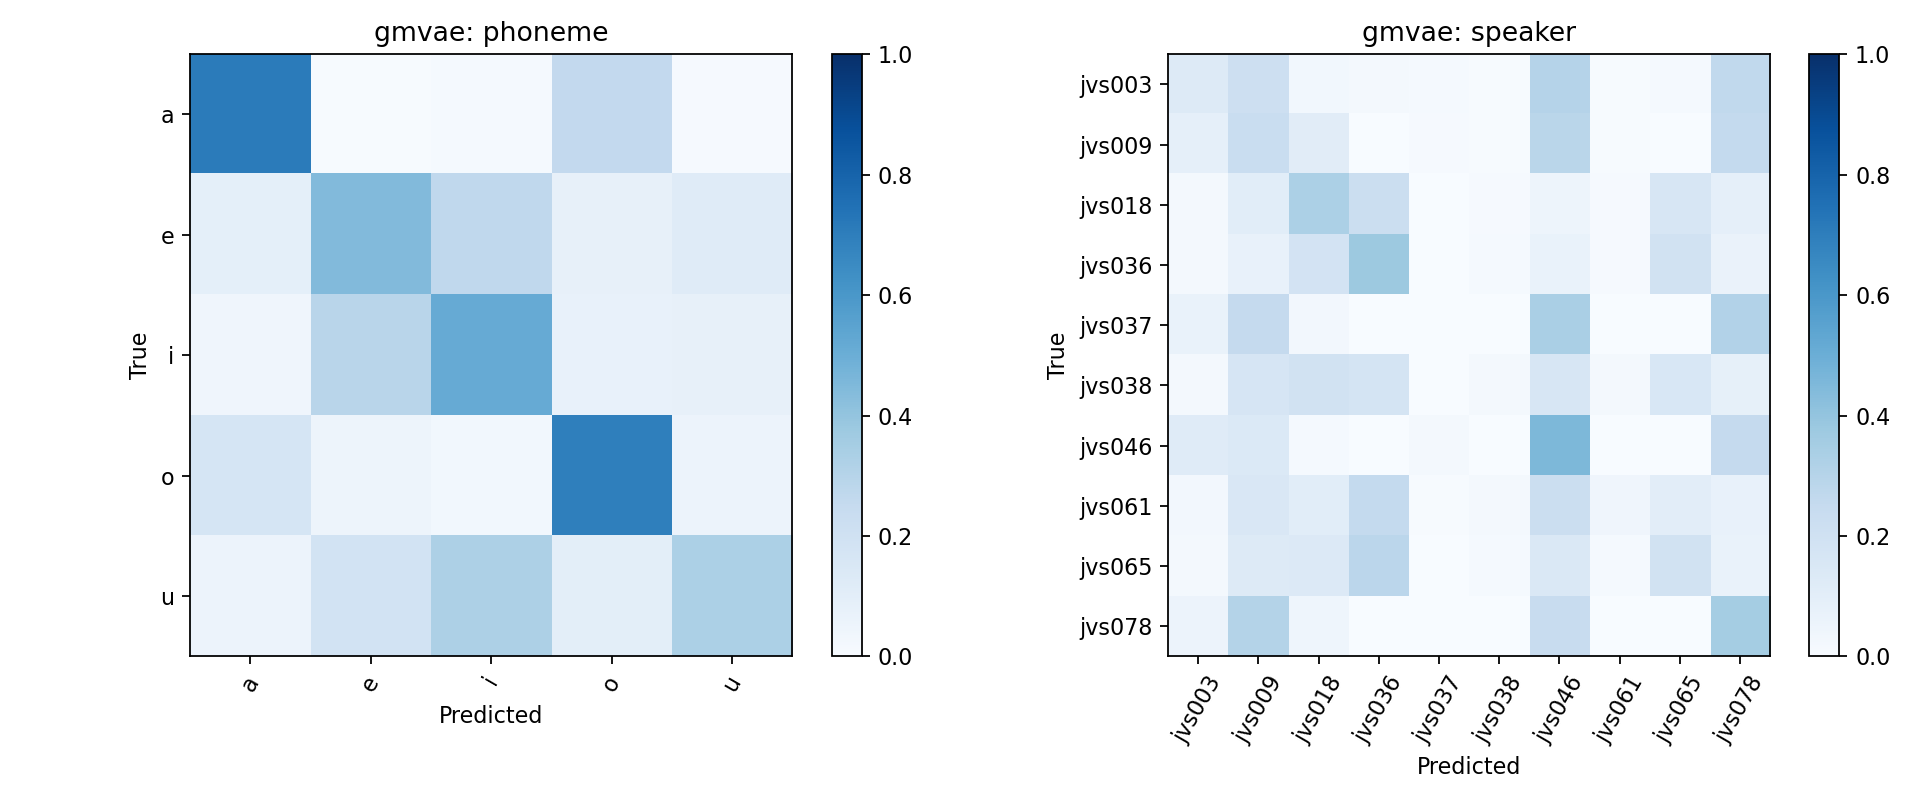

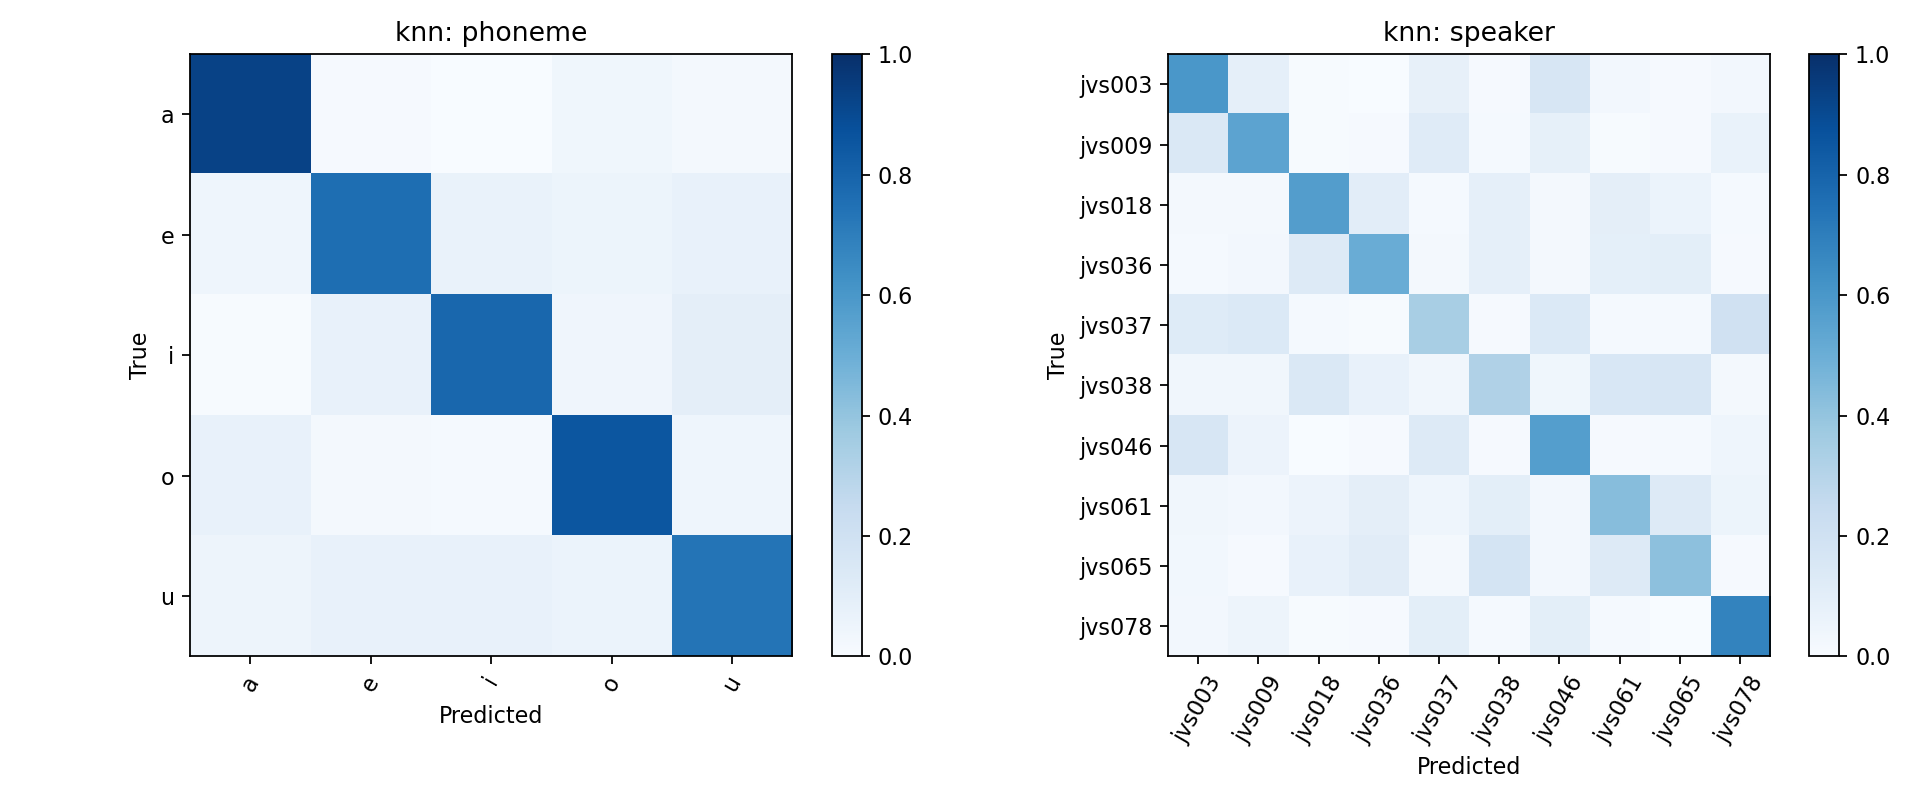

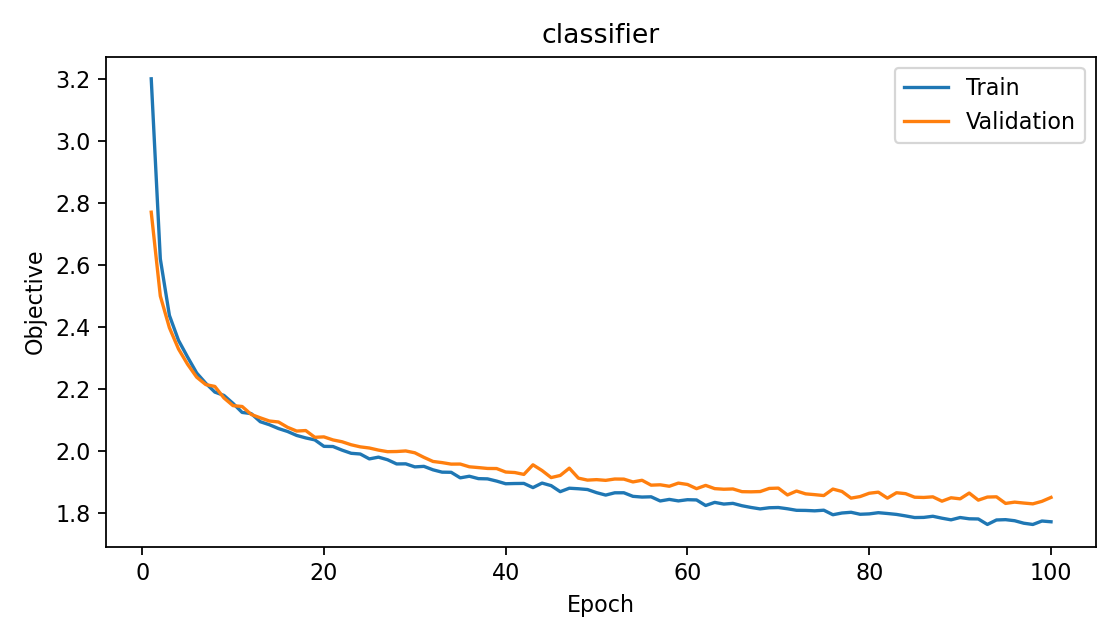

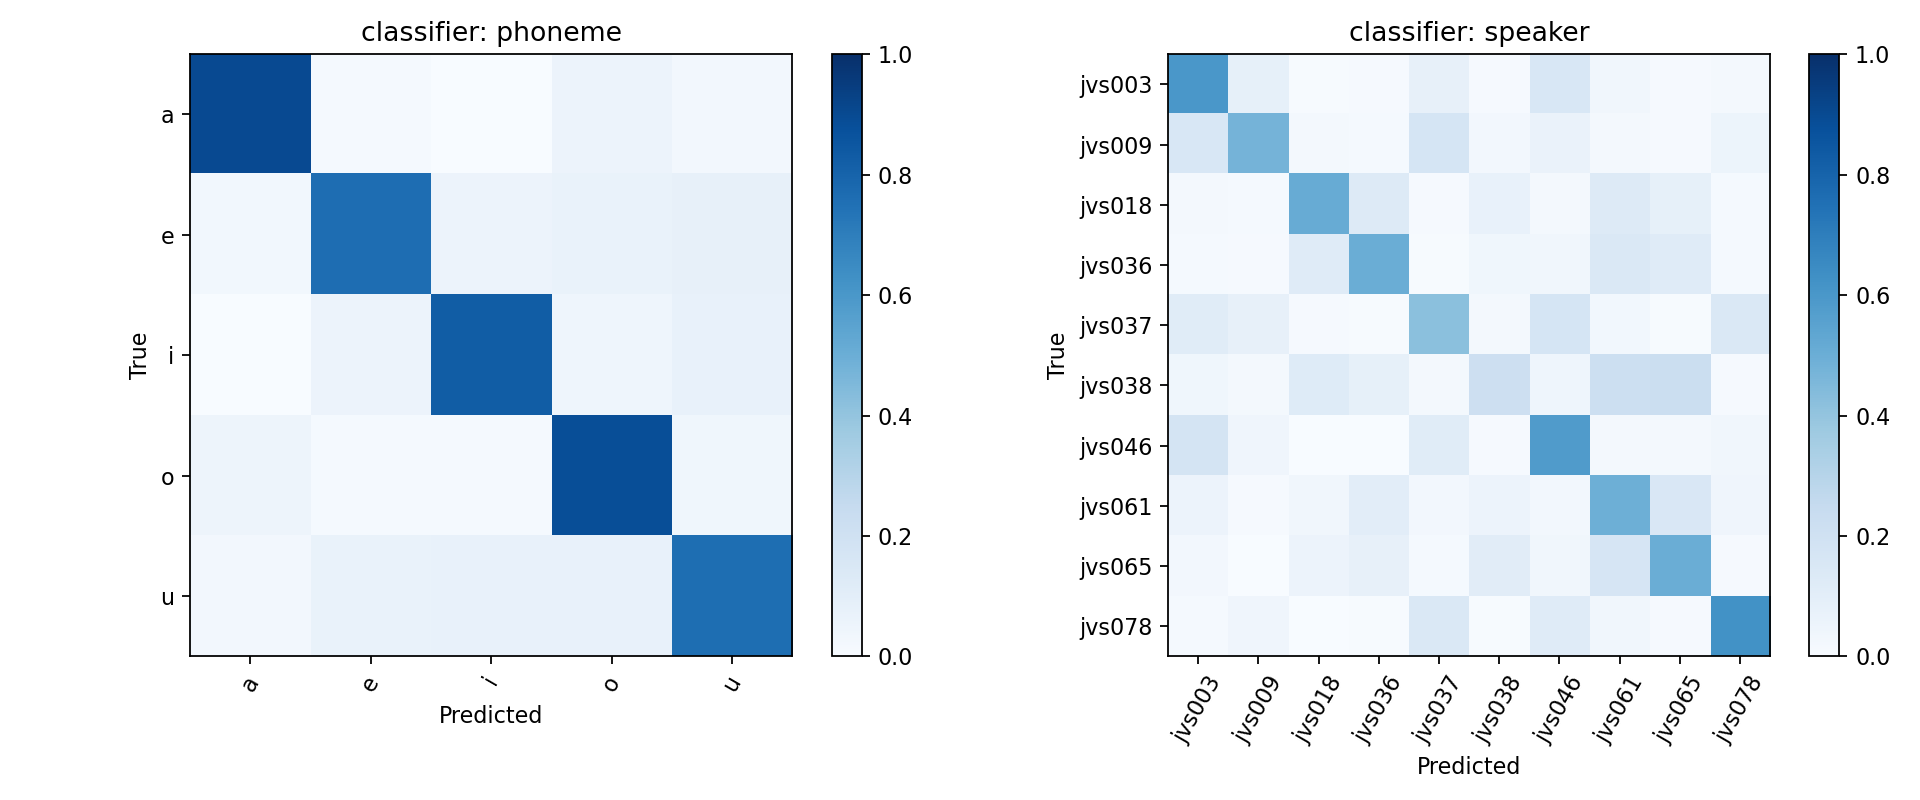

In [7]:
for method in config.methods:
    curve = run_dir / method / 'learning_curve.png'
    if curve.exists():
        display(Image(filename=str(curve)))
    display(Image(filename=str(run_dir / method / 'confusion_matrices.png')))

## 6. Check and reload the saved artifacts

Each run records the resolved config, CSV SHA-256, selected speakers, all split row IDs, training-only preprocessing, library versions/interpreter, histories, best model checkpoints, prediction tables, metrics, and figures. The model checkpoint contains architecture settings and label vocabularies; preprocessing is saved separately and must be reused for new observations.

The next cell verifies a reload of a neural checkpoint. It does not train again. Load joblib/PyTorch files only from runs you trust.

In [8]:
import torch
from src.config import ModelConfig
from src.evaluation import predict_neural

method = next((name for name in config.methods if name in ('gmvae', 'classifier')), None)
if method is not None:
    checkpoint = torch.load(run_dir / method / 'best.pt', map_location='cpu', weights_only=True)
    model_class = TwoFactorVaDE if method == 'gmvae' else VowelClassifier
    restored = model_class(checkpoint['input_dim'], len(checkpoint['phonemes']),
                           len(checkpoint['speakers']), ModelConfig(**checkpoint['model_config']))
    restored.load_state_dict(checkpoint['state_dict'])
    restored.eval()
    predicted, _ = predict_neural(restored, method, vowels.x['test'],
                                  config.training.batch_size, config.training.seed + 200)
    saved = pd.read_csv(run_dir / method / 'test_predictions.csv')
    assert np.array_equal(predicted, saved[['raw_category_1', 'raw_category_2']].to_numpy())
    print('Reloaded checkpoint reproduces all test category predictions.')

print('Saved files:')
for file in sorted(run_dir.rglob('*')):
    if file.is_file():
        print(file.relative_to(run_dir))

C:\Users\46021\.conda\envs\lffl\Lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Reloaded checkpoint reproduces all test category predictions.
Saved files:
accuracy.png
classifier\best.pt
classifier\confusion_matrices.png
classifier\history.csv
classifier\learning_curve.png
classifier\metrics.json
classifier\test_predictions.csv
classifier\val_predictions.csv
config.json
data.json
environment.json
gmvae\best.pt
gmvae\confusion_matrices.png
gmvae\history.csv
gmvae\label_mappings.json
gmvae\learning_curve.png
gmvae\metrics.json
gmvae\pretraining_history.csv
gmvae\test_predictions.csv
gmvae\val_predictions.csv
knn\confusion_matrices.png
knn\metrics.json
knn\model.joblib
knn\test_predictions.csv
knn\val_predictions.csv
metrics.json
preprocessing.joblib
split_manifest.csv
summary.csv


## Run again or transfer to a server

1. Edit `src/configs/vowels.py`, or copy it to another Python config.
2. Open this notebook with the intended Anaconda kernel and run all cells.
3. The equivalent command is `python src/train.py --config src/configs/vowels.py`.
4. Copy the repository plus the CSV to the server and create an environment from `src/environment.yml`. Paths in the config resolve relative to the project root; absolute paths are also supported.

The numerical verification command is `python -m unittest discover -s src/tests -v`. For noninteractive notebook execution using the current environment, use `python src/execute_notebook.py src/train_vowels.ipynb`. Slurm integration can be added later.